# Muspan - Spatial Analysis tool

## Domain

`MuSpan` is a Python Class that provides an object to store Spatial Biology data, with functions that can perform statistical analysis of the data.

An instance of the Class is called a `domain.`

In [4]:
# Import the MuSpan Library and other libraries we will need
import muspan as ms
import numpy as np
import matplotlib.pyplot as plt

# Create a new domain with the name Example
first_domain = ms.domain("Example")

# Print the details of the domain instance.
print(first_domain)

Domain name: Example
Number of objects: 0
Collections: []
Labels: [] 
Networks: [] 
Distance matrices: []


The constructor only requires a `Domain name` to create the instance. The documentation calls the data stored in the `domain` *objects*. So if we have the co-ordinates of 1000 transcripts loaded in, the syntax would be we had *a thousand objects loaded in*.

We can add some dummy data in to show how we can visiualise co-ordinates. Like the `domain` object itself, we will tag the data with a name so we can access this collection of data later.

The date will be saved in the `domain.objects` slot in the instance. If you do not label the data it will be labeled `default_collection`.

MuSpan uses matplotlib to visualise the objects, as `ggplot2` is in R and too good for them. The Namespace/Nested Object of bound fucntions to do this are in the `visualise` attribute.

In [5]:
# Add the generated points to the domain under the collection.
points = np.random.rand(100, 2)

# Add the points and label them.
first_domain.add_points(points, "Uniformly random points")

# What does our domain look like now?
print(first_domain)

Domain name: Example
Number of objects: 100
Collections: ['Uniformly random points']
Labels: [] 
Networks: [] 
Distance matrices: []


(<Figure size 1000x800 with 2 Axes>, <Axes: >)

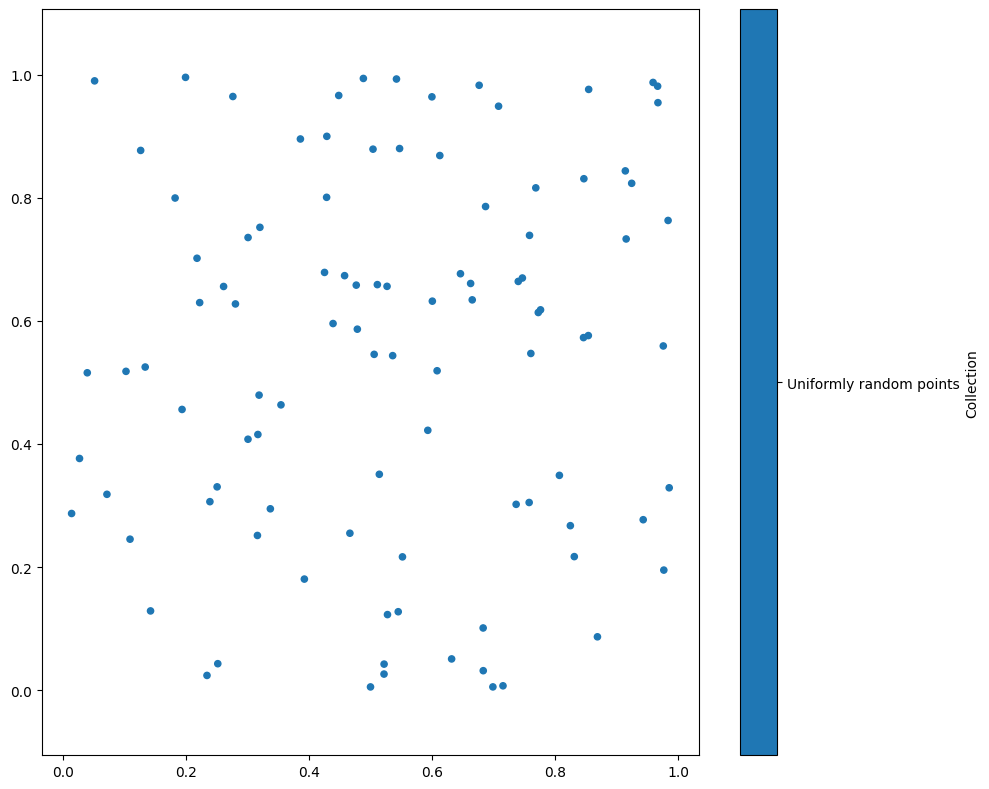

In [6]:
# Visualise the domain using the visualise funtion. 
ms.visualise.visualise(first_domain)

## Good boundaries, make good analysis

The plot shows the idea of the next major concept - **boundary**. In the real world, out transcripts or cells will not potential exist anywhere in the Universe. Rather, they will be found in clear areas we can draw a boundary around. 

For the later statistics this is important as many test use the density of points to generate null distributions against which to compare data, which is affected both by te number of points and the area of the domain.

MuSpan will infer a domain boundary if we do not tell it. We can access this boundary using the `domain.boundary` Getter.

Using the `visualise` Namespace bound methods again we can visualise the default boundary with the `show_boundary=True` parameter. The `boundary` is defined by it's `vertex`, the specific *where* in space that defines the shape of the boundary. The `vertex` property of the `boundary` slot will give us the IDs of the boundary vertices. We can use the vertices IDs to get the actual vertex values using the `vertices` property of the `domain`.

(<Figure size 800x500 with 2 Axes>, <Axes: >)

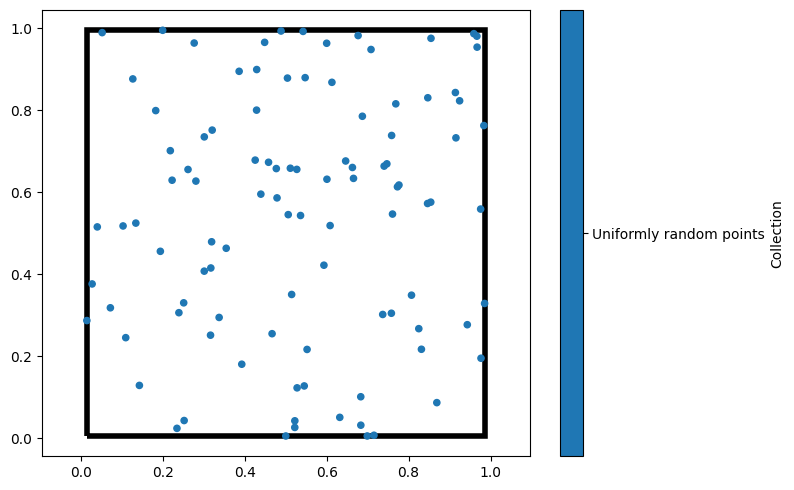

In [7]:
# Create a new figure.
plt.figure(figsize=(8, 5))

# Visualise the domain as before but this time show the boundary.
ms.visualise.visualise(first_domain, ax=plt.gca(), show_boundary=True)

In [8]:
# Get the vertex IDs.
boundary_vertex_IDs = first_domain.boundary.vertices
print(f"Vertex IDs: {boundary_vertex_IDs}")

# Print the coordinates of the boundary vertices.
print(f"Vertex coordinates: {first_domain.vertices[boundary_vertex_IDs]}")

# Print the area of the domain boundary.
print(f"Domain area: {first_domain.boundary.area}")

Vertex IDs: [104, 105, 106, 107]
Vertex coordinates: [[0.01451768 0.00518461]
 [0.01451768 0.99562987]
 [0.98551019 0.99562987]
 [0.98551019 0.00518461]]
Domain area: 0.9617149280057071


### Adding more points

We can add and tag more points into our domain. When visualising them, Muspan will colour each collection of points differently.